# UID Analysis: Active/Passive Alternations

Statistical analysis of Uniform Information Density (UID) effects from active↔passive conversion in the GUM corpus.

**Data files** (set `DATA_DIR` below):
- `sweep_tok_document.csv` — token-level UID for s_t across windows (-0,+0) to (-20,+20)
- `sweep_word_document.csv` — word-level UID for s_t across same windows
- `next_sent_uid.csv` — word-level UID for s_{t+1} after CF conversion
- `full_cf_traj.csv` — full document trajectory (run with `--score_all_cf_sents`; may not exist yet)

**Research questions**:
1. Does active↔passive conversion change the UID of the converted sentence?
2. Does it change how surprising the next sentence is? (discourse planning)
3. Does the effect grow with window size?
4. Does converting s_t cause a ripple through the document?
5. Is the a→p effect symmetric with p→a?

## 0 — Setup

In [2]:
import ast
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Adjust this path ──────────────────────────────────────────────────────────
DATA_DIR = Path("/Users/nolan/Documents/Data/UID")
# ─────────────────────────────────────────────────────────────────────────────

print("Data dir:", DATA_DIR)
print("Files:   ", [f.name for f in DATA_DIR.glob("*.csv")])

Data dir: /Users/nolan/Documents/Data/UID
Files:    ['sweep_word_document.csv', 'sweep_tok_document.csv', 'sweep_right_word.csv', 'next_sent_uid.csv']


## 1 — Data Loading & Pairing

Core pairing logic: each CF row is matched to its factual counterpart by `(doc_name, sent_idx, uid_level, context)`.

In [3]:
def parse_doc_id(doc_id):
    parts = str(doc_id).split("::")
    if len(parts) != 4:
        return pd.Series([None, None, None, None])
    return pd.Series(parts)


def load_and_parse(path):
    df = pd.read_csv(path, index_col=0, low_memory=False)
    df[["fact", "doc_name", "conv_id", "conv_type"]] = df["doc_id"].apply(parse_doc_id)
    df["genre"] = df["doc_name"].str.split("_").str[1]
    return df


def add_metrics_from_raw(df):
    """Compute new UID metrics from the raw_surps column (string → list).
    This lets us use surp_peak, uid_iqr, uid_skew, uid_gini, uid_roughness
    without re-running the pipeline.
    """
    from scipy.stats import skew as _skew

    def _gini(arr):
        n = len(arr)
        if n < 2 or arr.sum() == 0:
            return 0.0
        s = np.sort(arr)
        idx = np.arange(1, n + 1)
        return float((2.0 * (idx * s).sum()) / (n * s.sum()) - (n + 1) / n)

    def _row_metrics(raw_str):
        try:
            arr = np.array(ast.literal_eval(raw_str), dtype=float)
        except Exception:
            return [np.nan] * 5
        if len(arr) < 2:
            return [float(arr.max()) if len(arr) else np.nan, np.nan, 0.0, 0.0, 0.0]
        return [
            float(arr.max()),                                                    # surp_peak
            float(np.percentile(arr, 75) - np.percentile(arr, 25)),             # uid_iqr
            float(_skew(arr)) if arr.std() > 1e-10 else 0.0,                    # uid_skew
            _gini(arr),                                                          # uid_gini
            float(np.abs(np.diff(arr)).mean()),                                  # uid_roughness
        ]

    cols = ["surp_peak", "uid_iqr", "uid_skew", "uid_gini", "uid_roughness"]
    computed = df["raw_surps"].apply(_row_metrics).tolist()
    for i, col in enumerate(cols):
        df[col] = [row[i] for row in computed]
    return df


def make_pairs(df, merge_cols=("doc_name", "sent_idx", "uid_level", "context")):
    merge_cols = [c for c in merge_cols if c in df.columns]
    factual = df[df["fact"] == "f"].copy()
    cf      = df[df["fact"] == "cf"].copy()

    all_metrics = [
        "surp_mean", "surp_peak", "surp_slor",
        "uid_std", "uid_mad", "uid_iqr",
        "uid_pwd", "uid_roughness",
        "uid_range", "uid_cv", "uid_skew", "uid_gini",
        "uid_slope", "uid_len",
    ]
    metrics = [m for m in all_metrics if m in df.columns]

    paired = cf.merge(
        factual[[*merge_cols, "genre", *metrics]],
        on=merge_cols,
        suffixes=("_cf", "_f"),
    )
    for m in metrics:
        if f"{m}_cf" in paired.columns and f"{m}_f" in paired.columns:
            paired[f"delta_{m}"] = paired[f"{m}_cf"] - paired[f"{m}_f"]

    match_rate = len(paired) / len(cf) if len(cf) > 0 else 0
    print(f"  CF rows: {len(cf):,}  Paired: {len(paired):,}  Match rate: {match_rate:.1%}")
    return paired


# ── Load & enrich ─────────────────────────────────────────────────────────────
print("Loading sweep_tok_document.csv ...")
tok  = add_metrics_from_raw(load_and_parse(DATA_DIR / "sweep_tok_document.csv"))

print("Loading sweep_word_document.csv ...")
word = add_metrics_from_raw(load_and_parse(DATA_DIR / "sweep_word_document.csv"))

print("Loading sweep_right_word.csv ...")
right = add_metrics_from_raw(load_and_parse(DATA_DIR / "sweep_right_word.csv"))

print("Loading next_sent_uid.csv ...")
nxt  = add_metrics_from_raw(load_and_parse(DATA_DIR / "next_sent_uid.csv"))

traj_path = DATA_DIR / "full_cf_traj.csv"
traj = add_metrics_from_raw(load_and_parse(traj_path)) if traj_path.exists() else None
print(f"full_cf_traj.csv: {'loaded' if traj is not None else 'NOT FOUND'}")

# ── Pair ──────────────────────────────────────────────────────────────────────
print("\nPairing token sweep:")
tok_paired = make_pairs(tok)
print("Pairing word sweep:")
word_paired = make_pairs(word)
print("Pairing right-only word sweep:")
right_paired = make_pairs(right)
print("Pairing next-sentence:")
nxt_paired = make_pairs(nxt, merge_cols=("doc_name", "sent_idx", "context"))
traj_paired = make_pairs(traj) if traj is not None else None

Loading sweep_tok_document.csv ...
Loading sweep_word_document.csv ...
Loading sweep_right_word.csv ...
Loading next_sent_uid.csv ...
full_cf_traj.csv: NOT FOUND

Pairing token sweep:
  CF rows: 9,672  Paired: 9,672  Match rate: 100.0%
Pairing word sweep:
  CF rows: 8,407  Paired: 8,353  Match rate: 99.4%
Pairing right-only word sweep:
  CF rows: 9,655  Paired: 9,630  Match rate: 99.7%
Pairing next-sentence:
  CF rows: 2,297  Paired: 2,297  Match rate: 100.0%


In [4]:
# Conversion type counts
print("=== Conversion type breakdown ===")
for label, df in [
    ("tok sweep (sym)", tok_paired),
    ("word sweep (sym)", word_paired),
    ("right word sweep", right_paired),
    ("next-sent", nxt_paired),
]:
    counts = df["conv_type"].value_counts()
    print(f"\n{label}:")
    print(counts.to_string())
    ratio = counts.get("a>p", 0) / max(counts.get("p>a", 1), 1)
    print(f"  a>p / p>a ratio: {ratio:.1f}x")
    if counts.get("p>a", 0) < 200:
        print("  ⚠ p>a has low n — interpret with caution")
    else:
        print("  p>a n is adequate")

=== Conversion type breakdown ===

tok sweep (sym):
conv_type
a>p    9118
p>a     554
  a>p / p>a ratio: 16.5x
  p>a n is adequate

word sweep (sym):
conv_type
a>p    7896
p>a     457
  a>p / p>a ratio: 17.3x
  p>a n is adequate

right word sweep:
conv_type
a>p    9090
p>a     540
  a>p / p>a ratio: 16.8x
  p>a n is adequate

next-sent:
conv_type
a>p    2164
p>a     133
  a>p / p>a ratio: 16.3x
  ⚠ p>a has low n — interpret with caution


## 2 — Descriptive Statistics & Visualisation

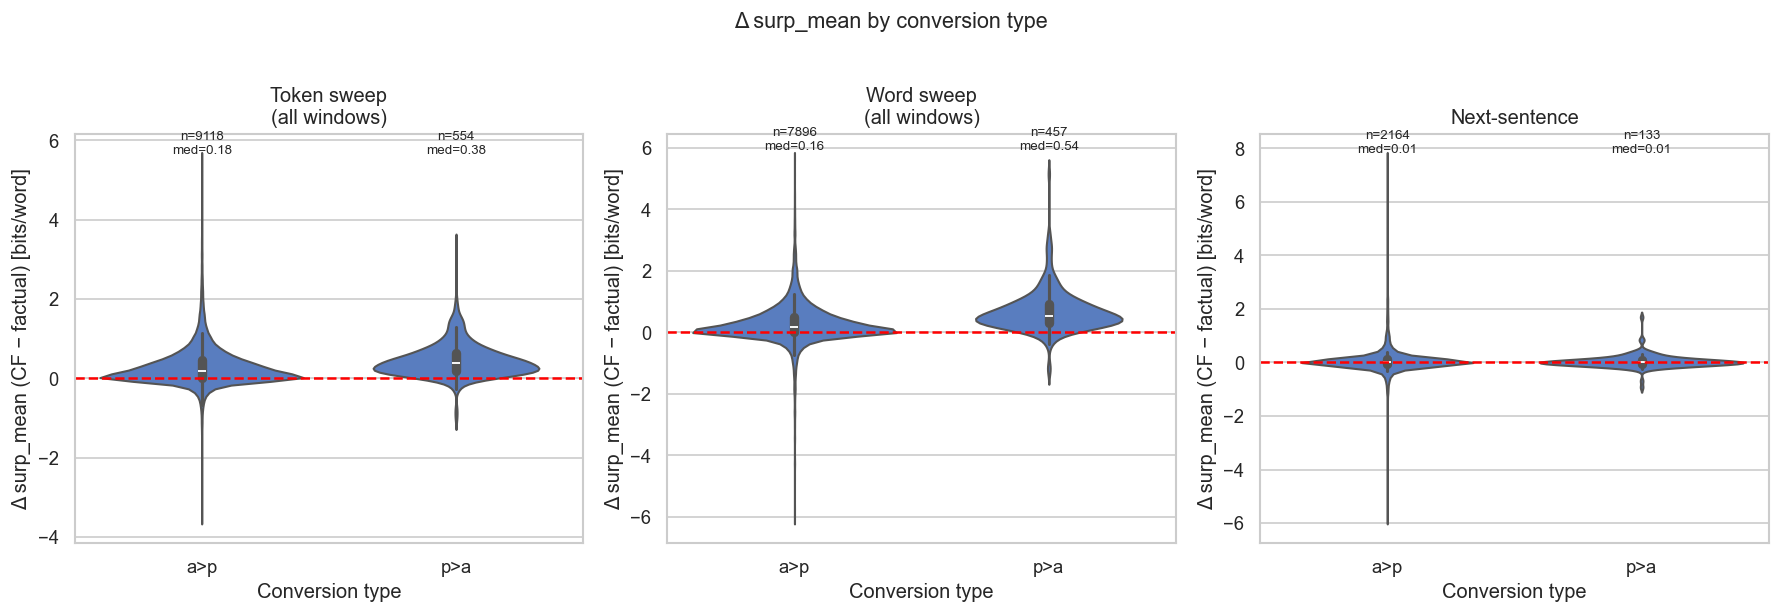

In [5]:
# 2a. Paired delta distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (label, df) in zip(axes, [
    ("Token sweep\n(all windows)", tok_paired),
    ("Word sweep\n(all windows)", word_paired),
    ("Next-sentence", nxt_paired),
]):
    sns.violinplot(
        data=df, x="conv_type", y="delta_surp_mean",
        order=["a>p", "p>a"], inner="box", ax=ax,
    )
    ax.axhline(0, color="red", lw=1.5, ls="--", label="no effect")
    ax.set_title(label)
    ax.set_xlabel("Conversion type")
    ax.set_ylabel("Δ surp_mean (CF − factual) [bits/word]")
    for ct in ["a>p", "p>a"]:
        sub = df[df["conv_type"] == ct]["delta_surp_mean"].dropna()
        ax.text(
            ["a>p", "p>a"].index(ct),
            ax.get_ylim()[1] * 0.92,
            f"n={len(sub)}\nmed={sub.median():.2f}",
            ha="center", fontsize=8,
        )

plt.suptitle("Δ surp_mean by conversion type", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_delta_distributions.png", bbox_inches="tight")
plt.show()

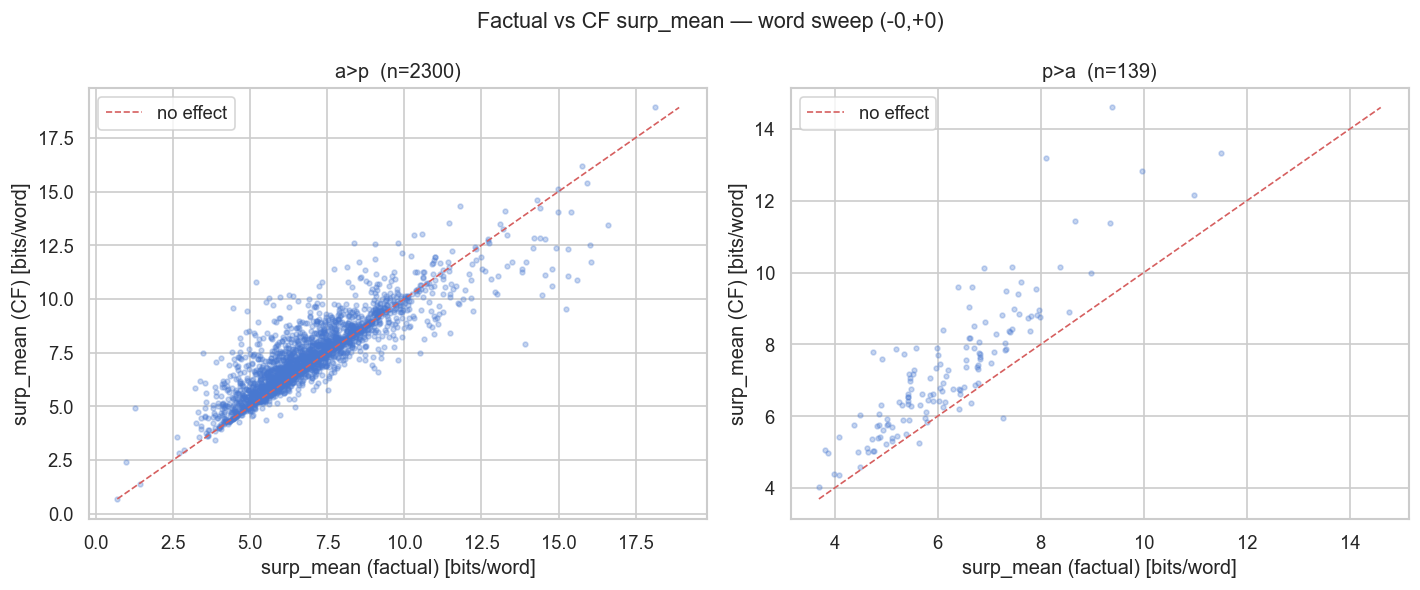

In [6]:
# 2b. Scatter: factual vs CF surp_mean (word sweep, (-0,+0) window only)
sub = word_paired[word_paired["uid_level"] == "(-0,+0)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ct in zip(axes, ["a>p", "p>a"]):
    d = sub[sub["conv_type"] == ct]
    ax.scatter(d["surp_mean_f"], d["surp_mean_cf"], alpha=0.3, s=8)
    lim = (min(d["surp_mean_f"].min(), d["surp_mean_cf"].min()),
           max(d["surp_mean_f"].max(), d["surp_mean_cf"].max()))
    ax.plot(lim, lim, "r--", lw=1, label="no effect")
    ax.set_xlabel("surp_mean (factual) [bits/word]")
    ax.set_ylabel("surp_mean (CF) [bits/word]")
    ax.set_title(f"{ct}  (n={len(d)})")
    ax.legend()

plt.suptitle("Factual vs CF surp_mean — word sweep (-0,+0)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_scatter_factual_cf.png", bbox_inches="tight")
plt.show()

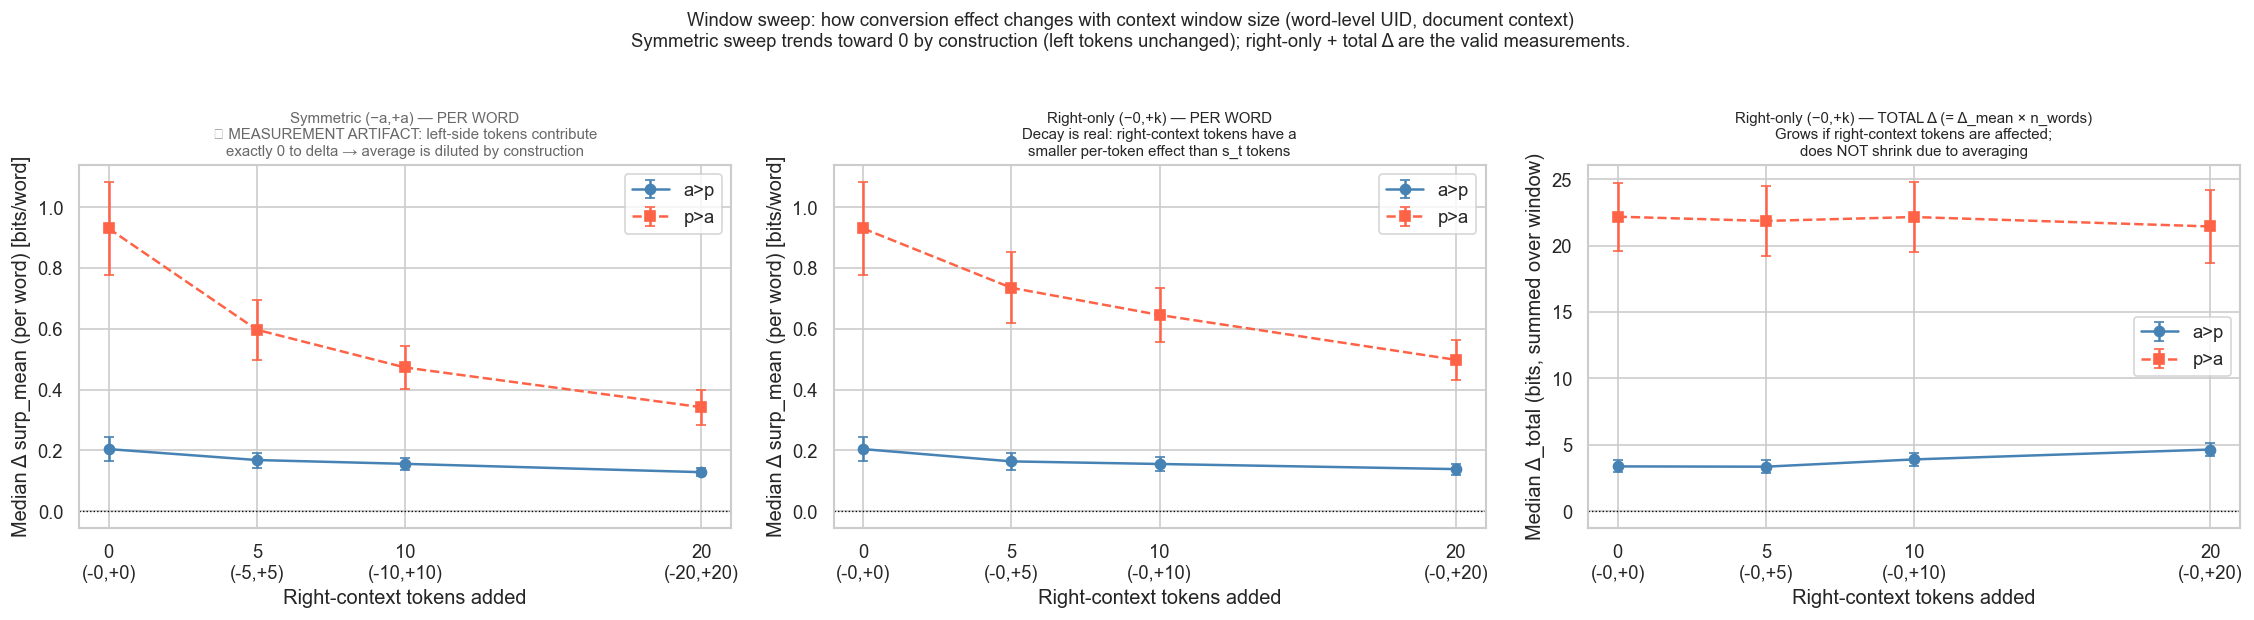

Δ_total verification (a>p, window (-0,+0)):
  median Δ_mean  = 0.2043 bits/word
  median uid_len_f = 16.0 words
  expected Δ_total ≈ 3.2694 bits  (product of medians)
  actual   Δ_total (median of per-row products) = 3.3754 bits


In [7]:
# 2c. Window sweep — three panels
#
# Panel 1 (LEFT):   Symmetric (-a,+a) — per-word Δ surp_mean
#   ARTIFACT: left-side context tokens are IDENTICAL between factual and CF
#   in a causal LM (same preceding text), so they contribute exactly 0 to the
#   CF−factual delta.  Adding them only inflates the denominator → per-word
#   average trends to 0 purely by construction, NOT because the effect shrinks.
#
# Panel 2 (CENTER): Right-only (-0,+k) — per-word Δ surp_mean
#   This is the clean measurement.  The decay is real: right-context tokens
#   have a smaller per-token effect than the converted sentence tokens, but
#   that is informative (the effect decays into s_{t+1}).
#
# Panel 3 (RIGHT):  Right-only (-0,+k) — Δ_total = Δ_mean × uid_len
#   surp_mean = total_surprisal / uid_len, so total_surprisal = surp_mean × uid_len.
#   Δ_total grows if right-context tokens are genuinely affected; it does NOT
#   shrink due to averaging.  This directly refutes the "effect shrinks" reading.

SYM_RIGHT  = {"(-0,+0)": 0, "(-5,+5)":  5, "(-10,+10)": 10, "(-20,+20)": 20}
RIGHT_ONLY = {"(-0,+0)": 0, "(-0,+5)":  5, "(-0,+10)":  10, "(-0,+20)":  20}

assert "uid_len_f" in right_paired.columns, \
    "uid_len_f missing from right_paired — check make_pairs() all_metrics list"

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
ax_sym, ax_right, ax_total = axes

for conv_type, ls, marker in [("a>p", "-", "o"), ("p>a", "--", "s")]:
    color = "steelblue" if conv_type == "a>p" else "tomato"

    # ── Panel 1: Symmetric sweep (per-word, artifact) ──────────────────────
    xs, meds, cis = [], [], []
    for w, x in SYM_RIGHT.items():
        sub = word_paired[
            (word_paired["uid_level"] == w) & (word_paired["conv_type"] == conv_type)
        ]["delta_surp_mean"].dropna()
        if len(sub) < 5:
            continue
        xs.append(x); meds.append(sub.median())
        cis.append(stats.sem(sub) * stats.t.ppf(0.975, len(sub) - 1))
    ax_sym.errorbar(xs, meds, yerr=cis, marker=marker, color=color,
                    linestyle=ls, capsize=3, label=conv_type)

    # ── Panel 2: Right-only sweep (per-word) ───────────────────────────────
    xs_r, meds_r, cis_r = [], [], []
    for w, x in RIGHT_ONLY.items():
        sub = right_paired[
            (right_paired["uid_level"] == w) & (right_paired["conv_type"] == conv_type)
        ]["delta_surp_mean"].dropna()
        if len(sub) < 5:
            continue
        xs_r.append(x); meds_r.append(sub.median())
        cis_r.append(stats.sem(sub) * stats.t.ppf(0.975, len(sub) - 1))
    ax_right.errorbar(xs_r, meds_r, yerr=cis_r, marker=marker, color=color,
                      linestyle=ls, capsize=3, label=conv_type)

    # ── Panel 3: Right-only Δ_total = Δ_mean × uid_len ────────────────────
    xs_t, totals, cis_t = [], [], []
    for w, x in RIGHT_ONLY.items():
        sub_w = right_paired[
            (right_paired["uid_level"] == w) & (right_paired["conv_type"] == conv_type)
        ].copy()
        sub_w = sub_w.dropna(subset=["surp_mean_cf", "surp_mean_f", "uid_len_f"])
        if len(sub_w) < 5:
            continue
        sub_w["delta_surp_mean"] = sub_w["surp_mean_cf"] - sub_w["surp_mean_f"]
        sub_w["delta_total"] = sub_w["delta_surp_mean"] * sub_w["uid_len_f"]
        xs_t.append(x)
        totals.append(sub_w["delta_total"].median())
        cis_t.append(stats.sem(sub_w["delta_total"]) *
                     stats.t.ppf(0.975, len(sub_w) - 1))
    ax_total.errorbar(xs_t, totals, yerr=cis_t, marker=marker, color=color,
                      linestyle=ls, capsize=3, label=conv_type)

# ── Panel formatting ────────────────────────────────────────────────────────
for ax in axes:
    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_xticks([0, 5, 10, 20])
    ax.set_xlabel("Right-context tokens added")
    ax.legend()

ax_sym.set_xticklabels(["0\n(-0,+0)", "5\n(-5,+5)", "10\n(-10,+10)", "20\n(-20,+20)"])
ax_right.set_xticklabels(["0\n(-0,+0)", "5\n(-0,+5)", "10\n(-0,+10)", "20\n(-0,+20)"])
ax_total.set_xticklabels(["0\n(-0,+0)", "5\n(-0,+5)", "10\n(-0,+10)", "20\n(-0,+20)"])

ax_sym.set_ylabel("Median \u0394 surp_mean (per word) [bits/word]")
ax_sym.set_title(
    "Symmetric (\u2212a,+a) \u2014 PER WORD\n"
    "\u26a0 MEASUREMENT ARTIFACT: left-side tokens contribute\n"
    "exactly 0 to delta \u2192 average is diluted by construction",
    color="dimgrey", fontsize=9,
)

ax_right.set_ylabel("Median \u0394 surp_mean (per word) [bits/word]")
ax_right.set_title(
    "Right-only (\u22120,+k) \u2014 PER WORD\n"
    "Decay is real: right-context tokens have a\n"
    "smaller per-token effect than s_t tokens",
    fontsize=9,
)

ax_total.set_ylabel("Median \u0394_total (bits, summed over window)")
ax_total.set_title(
    "Right-only (\u22120,+k) \u2014 TOTAL \u0394 (= \u0394_mean \xd7 n_words)\n"
    "Grows if right-context tokens are affected;\n"
    "does NOT shrink due to averaging",
    fontsize=9,
)

fig.suptitle(
    "Window sweep: how conversion effect changes with context window size "
    "(word-level UID, document context)\n"
    "Symmetric sweep trends toward 0 by construction (left tokens unchanged); "
    "right-only + total \u0394 are the valid measurements.",
    fontsize=11, y=1.03,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_window_sweep_comparison.png", bbox_inches="tight")
plt.show()

print("\u0394_total verification (a>p, window (-0,+0)):")
_chk = right_paired[(right_paired["uid_level"] == "(-0,+0)") & (right_paired["conv_type"] == "a>p")]
_chk = _chk.dropna(subset=["surp_mean_cf", "surp_mean_f", "uid_len_f"])
_dm  = (_chk["surp_mean_cf"] - _chk["surp_mean_f"]).median()
_dl  = _chk["uid_len_f"].median()
print(f"  median \u0394_mean  = {_dm:.4f} bits/word")
print(f"  median uid_len_f = {_dl:.1f} words")
print(f"  expected \u0394_total \u2248 {_dm * _dl:.4f} bits  (product of medians)")
print(f"  actual   \u0394_total (median of per-row products) = "
      f"{((_chk['surp_mean_cf'] - _chk['surp_mean_f']) * _chk['uid_len_f']).median():.4f} bits")


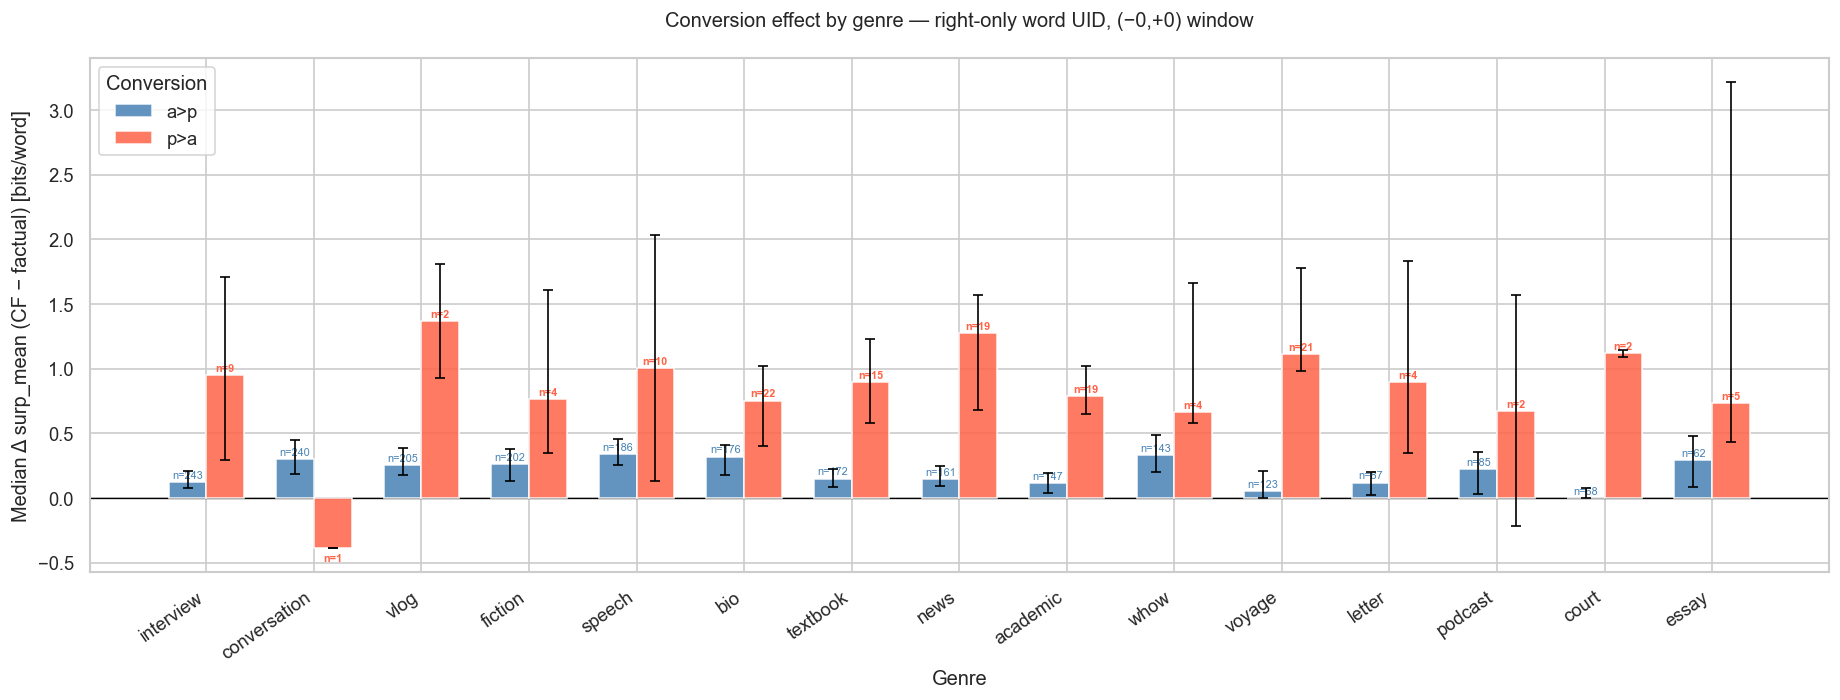


Included genres (15): ['academic', 'bio', 'conversation', 'court', 'essay', 'fiction', 'interview', 'letter', 'news', 'podcast', 'speech', 'textbook', 'vlog', 'voyage', 'whow']
Excluded genres  (0): []

Genre breakdown table (included only, n ≥ 10):
       genre conv_type   n    median     ci_lo    ci_hi
    academic       a>p 147  0.112548  0.039680 0.190428
    academic       p>a  19  0.785896  0.651245 1.021627
         bio       a>p 176  0.320186  0.178466 0.409973
         bio       p>a  22  0.753042  0.398361 1.018412
conversation       a>p 240  0.298647  0.188599 0.447583
conversation       p>a   1 -0.389561       NaN      NaN
       court       a>p  68  0.000000  0.000000 0.079153
       court       p>a   2  1.119894  1.093073 1.146714
       essay       a>p  62  0.290211  0.086179 0.481208
       essay       p>a   5  0.732659  0.435475 3.219328
     fiction       a>p 202  0.264777  0.132827 0.378294
     fiction       p>a   4  0.766322  0.351259 1.610108
   interview       a>

In [ ]:
# 2d. Genre breakdown — right-only word UID, (-0,+0) window
#
# Genres with insufficient n are EXCLUDED from the plot and listed in a footnote.
# This prevents n=1 bars from misleading readers about effect reliability.
# Error bars are 95% bootstrap CIs (non-parametric; appropriate for skewed data).

MIN_GENRE_N  = 10    # minimum n per conv_type to include a genre in the plot
BOOTSTRAP_B  = 1000  # bootstrap resamples for CI
_RNG = np.random.default_rng(42)


def _bootstrap_ci(arr, B=BOOTSTRAP_B, rng=_RNG):
    """Return (median, lower_95, upper_95) via percentile bootstrap."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) < 2:
        return (float(np.median(arr)) if len(arr) == 1 else np.nan), np.nan, np.nan
    boot = rng.choice(arr, size=(B, len(arr)), replace=True)
    m = np.median(boot, axis=1)
    return float(np.median(arr)), float(np.percentile(m, 2.5)), float(np.percentile(m, 97.5))


sub = right_paired[right_paired["uid_level"] == "(-0,+0)"].copy()
genre_col = "genre_f" if "genre_f" in sub.columns else "genre"

# ── Build per-(genre, conv_type) summary ────────────────────────────────────
records = []
for genre, grp in sub.groupby(genre_col):
    for ct in ["a>p", "p>a"]:
        vals = grp[grp["conv_type"] == ct]["delta_surp_mean"].dropna()
        n = len(vals)
        med, lo, hi = _bootstrap_ci(vals)
        records.append({"genre": genre, "conv_type": ct, "n": n,
                         "median": med, "ci_lo": lo, "ci_hi": hi})
genre_df = pd.DataFrame(records)

# ── Filter: include genre if ANY conv_type has n >= MIN_GENRE_N ─────────────
genre_max_n     = genre_df.groupby("genre")["n"].max()
included_genres = sorted(genre_max_n[genre_max_n >= MIN_GENRE_N].index)
excluded_genres = sorted(genre_max_n[genre_max_n <  MIN_GENRE_N].index)

# Sort included genres by a>p n descending
ap_n_by_genre = (genre_df[genre_df["conv_type"] == "a>p"]
                 .set_index("genre")["n"]
                 .reindex(included_genres, fill_value=0))
sort_order = ap_n_by_genre.sort_values(ascending=False).index.tolist()

cts    = ["a>p", "p>a"]
colors = {"a>p": "steelblue", "p>a": "tomato"}
x      = np.arange(len(sort_order))
width  = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(sort_order) * 0.9 + 2), 6))

for i, ct in enumerate(cts):
    offset  = (i - 0.5) * width
    ct_data = genre_df[genre_df["conv_type"] == ct].set_index("genre")

    vals  = [ct_data.loc[g, "median"] if g in ct_data.index else np.nan for g in sort_order]
    lo    = [ct_data.loc[g, "ci_lo"]  if g in ct_data.index else np.nan for g in sort_order]
    hi    = [ct_data.loc[g, "ci_hi"]  if g in ct_data.index else np.nan for g in sort_order]
    ns    = [int(ct_data.loc[g, "n"]) if g in ct_data.index else 0       for g in sort_order]

    err_lo = [v - l if not (np.isnan(v) or np.isnan(l)) else 0 for v, l in zip(vals, lo)]
    err_hi = [h - v if not (np.isnan(v) or np.isnan(h)) else 0 for v, h in zip(vals, hi)]

    bars = ax.bar(x + offset, vals, width, color=colors[ct], label=ct, alpha=0.85, zorder=3)
    ax.errorbar(x + offset, vals, yerr=[err_lo, err_hi],
                fmt="none", color="black", capsize=3, lw=1, zorder=4)

    for j, (bar, g) in enumerate(zip(bars, sort_order)):
        n_val = ns[j]
        if n_val == 0:
            continue
        h = bar.get_height()
        if np.isnan(h):
            h = 0.0
        y_text = h + 0.015 if h >= 0 else h - 0.035
        va     = "bottom"  if h >= 0 else "top"
        weight = "bold" if n_val < 30 else "normal"
        ax.text(bar.get_x() + bar.get_width() / 2, y_text,
                f"n={n_val}", ha="center", va=va,
                fontsize=6.5, color=colors[ct], fontweight=weight)

ax.axhline(0, color="black", lw=0.8, zorder=2)
ax.set_xlabel("Genre")
ax.set_ylabel("Median \u0394 surp_mean (CF \u2212 factual)")
ax.set_title(
    f"Conversion effect by genre \u2014 right-only word UID, (\u22120,+0) window\n"
    # f"Error bars = 95% bootstrap CI (B={BOOTSTRAP_B}).  "
    # f"Only genres with n \u2265 {MIN_GENRE_N} shown.  "
    # f"Bold n = caution (n < 30)."
)
ax.legend(title="Conversion")
ax.set_xticks(x)
ax.set_xticklabels(sort_order, rotation=35, ha="right")

# ── Footnote listing excluded genres ────────────────────────────────────────
if excluded_genres:
    excl_parts = []
    for g in excluded_genres:
        _row = genre_df[genre_df["genre"] == g]
        _ap  = _row[_row["conv_type"] == "a>p"]["n"].values
        _pa  = _row[_row["conv_type"] == "p>a"]["n"].values
        excl_parts.append(
            f"{g} (a>p n={int(_ap[0]) if len(_ap) else 0}, "
            f"p>a n={int(_pa[0]) if len(_pa) else 0})"
        )
    ax.annotate(
        f"Excluded (n < {MIN_GENRE_N} for all conv types): " + "; ".join(excl_parts),
        xy=(0, -0.22), xycoords="axes fraction",
        va="top", fontsize=7, color="grey",
    )

plt.tight_layout()
plt.savefig(DATA_DIR / "fig_genre_breakdown.png", bbox_inches="tight")
plt.show()

print(f"\nIncluded genres ({len(included_genres)}): {included_genres}")
print(f"Excluded genres  ({len(excluded_genres)}): {excluded_genres}")
print(f"\nGenre breakdown table (included only, n \u2265 {MIN_GENRE_N}):")
print(genre_df[genre_df["genre"].isin(included_genres)]
      .sort_values(["genre", "conv_type"]).to_string(index=False))


## 3 — Wilcoxon Signed-Rank Tests

Non-parametric paired test — appropriate because surprisal distributions are right-skewed.
Bonferroni correction applied across windows × conv_types.

In [9]:
def run_wilcoxon_table(paired_df, label, metric="surp_mean"):
    rows = []
    uid_levels = paired_df["uid_level"].unique() if "uid_level" in paired_df.columns else ["sentence"]
    for uid_level in uid_levels:
        for ct in ["a>p", "p>a"]:
            mask = paired_df["conv_type"] == ct
            if "uid_level" in paired_df.columns:
                mask &= paired_df["uid_level"] == uid_level
            sub = paired_df[mask][[f"{metric}_cf", f"{metric}_f"]].dropna()
            if len(sub) < 10:
                continue
            try:
                res = pg.wilcoxon(sub[f"{metric}_cf"], sub[f"{metric}_f"])
                rows.append({
                    "dataset": label,
                    "uid_level": uid_level,
                    "conv_type": ct,
                    "n": len(sub),
                    "median_delta": (sub[f"{metric}_cf"] - sub[f"{metric}_f"]).median(),
                    "W": res["W_val"].iloc[0],
                    "p_raw": res["p_val"].iloc[0],
                    "RBC": res["RBC"].iloc[0],
                })
            except Exception as e:
                print(f"  Skipped {uid_level} {ct}: {e}")
    return pd.DataFrame(rows)


results = []
for label, df in [
    ("tok_sweep", tok_paired),
    ("word_sweep", word_paired),
    ("right_word_sweep", right_paired),
    ("next_sent", nxt_paired),
]:
    print(f"Running Wilcoxon for {label}...")
    r = run_wilcoxon_table(df, label)
    results.append(r)

wilcoxon_results = pd.concat(results, ignore_index=True)

if wilcoxon_results.empty:
    print("No Wilcoxon results computed — check data.")
else:
    _, wilcoxon_results["p_bonf"], _, _ = multipletests(wilcoxon_results["p_raw"], method="bonferroni")
    _, wilcoxon_results["p_fdr"],  _, _ = multipletests(wilcoxon_results["p_raw"], method="fdr_bh")
    wilcoxon_results["sig_bonf"] = wilcoxon_results["p_bonf"] < 0.05
    wilcoxon_results["sig_fdr"]  = wilcoxon_results["p_fdr"]  < 0.05

    pd.set_option("display.float_format", "{:.4f}".format)
    display(wilcoxon_results.sort_values(["dataset", "uid_level", "conv_type"]))

Running Wilcoxon for tok_sweep...
Running Wilcoxon for word_sweep...
Running Wilcoxon for right_word_sweep...
Running Wilcoxon for next_sent...


,dataset,uid_level,conv_type,n,median_delta,W,p_raw,RBC,p_bonf,p_fdr,sig_bonf,sig_fdr
24,next_sent,sentence,a>p,2164,0.0066,850653.0000,0.0000,0.1682,0.0000,0.0000,True,True
25,next_sent,sentence,p>a,133,0.0073,3751.0000,0.1139,0.1581,1.0000,0.1139,False,False
16,right_word_sweep,"(-0,+0)",a>p,2300,0.2043,523743.0000,0.0000,0.5449,0.0000,0.0000,True,True
17,right_word_sweep,"(-0,+0)",p>a,139,0.9301,150.0000,0.0000,0.9692,0.0000,0.0000,True,True
20,right_word_sweep,"(-0,+10)",a>p,2268,0.1554,465132.0000,0.0000,0.5839,0.0000,0.0000,True,True
21,right_word_sweep,"(-0,+10)",p>a,133,0.6456,156.0000,0.0000,0.9650,0.0000,0.0000,True,True
22,right_word_sweep,"(-0,+20)",a>p,2250,0.1385,406213.0000,0.0000,0.6324,0.0000,0.0000,True,True
23,right_word_sweep,"(-0,+20)",p>a,134,0.4980,190.0000,0.0000,0.9580,0.0000,0.0000,True,True
18,right_word_sweep,"(-0,+5)",a>p,2272,0.1639,515799.0000,0.0000,0.5403,0.0000,0.0000,True,True
19,right_word_sweep,"(-0,+5)",p>a,134,0.7350,147.0000,0.0000,0.9675,0.0000,0.0000,True,True


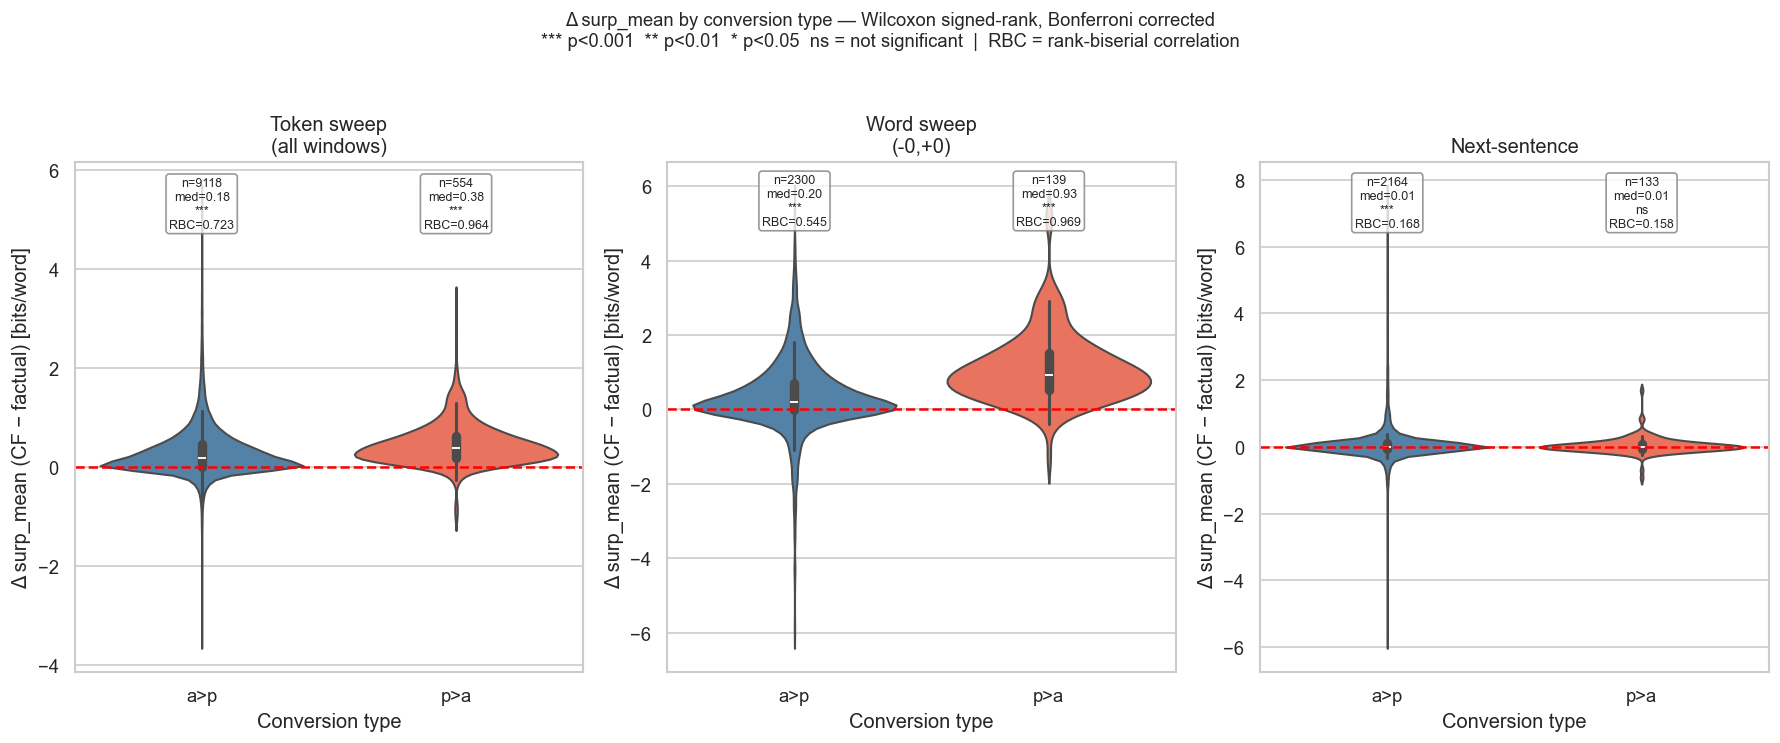

In [10]:
# 3a. Significance-annotated violin plots
# Adds Wilcoxon Bonferroni-corrected p-value stars and RBC effect size to the
# violin plots from Cell 7.  Requires wilcoxon_results (Cell 12).

def _sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

plot_specs = [
    ("Token sweep\n(all windows)",  tok_paired,
     "tok_sweep", None),
    ("Word sweep\n(-0,+0)",
     right_paired[right_paired["uid_level"] == "(-0,+0)"],
     "right_word_sweep", "(-0,+0)"),
    ("Next-sentence", nxt_paired,
     "next_sent", "sentence"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)

for ax, (label, df, dataset_key, uid_lvl) in zip(axes, plot_specs):
    sns.violinplot(
        data=df, x="conv_type", y="delta_surp_mean",
        order=["a>p", "p>a"], inner="box", ax=ax,
        palette={"a>p": "steelblue", "p>a": "tomato"},
    )
    ax.axhline(0, color="red", lw=1.5, ls="--")
    ax.set_title(label)
    ax.set_xlabel("Conversion type")
    ax.set_ylabel("\u0394 surp_mean (CF \u2212 factual) [bits/word]")

    y_max = ax.get_ylim()[1]
    for i_ct, ct in enumerate(["a>p", "p>a"]):
        sub = df[df["conv_type"] == ct]["delta_surp_mean"].dropna()
        n   = len(sub)
        med = sub.median()

        # Look up Bonferroni-corrected p and RBC
        mask = ((wilcoxon_results["dataset"] == dataset_key) &
                (wilcoxon_results["conv_type"] == ct))
        if uid_lvl is not None:
            mask &= (wilcoxon_results["uid_level"] == uid_lvl)
        row = wilcoxon_results[mask]
        if len(row) > 0:
            p_bonf = row.iloc[0]["p_bonf"]
            rbc    = row.iloc[0]["RBC"]
            stars  = _sig_stars(p_bonf)
            annot  = f"n={n}\nmed={med:.2f}\n{stars}\nRBC={rbc:.3f}"
        else:
            annot  = f"n={n}\nmed={med:.2f}\n(no test)"

        ax.text(i_ct, y_max * 0.95, annot,
                ha="center", va="top", fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="grey"))

plt.suptitle(
    "\u0394 surp_mean by conversion type \u2014 Wilcoxon signed-rank, Bonferroni corrected\n"
    "*** p<0.001  ** p<0.01  * p<0.05  ns = not significant  |  RBC = rank-biserial correlation",
    y=1.03, fontsize=11,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_delta_distributions_annotated.png", bbox_inches="tight")
plt.show()


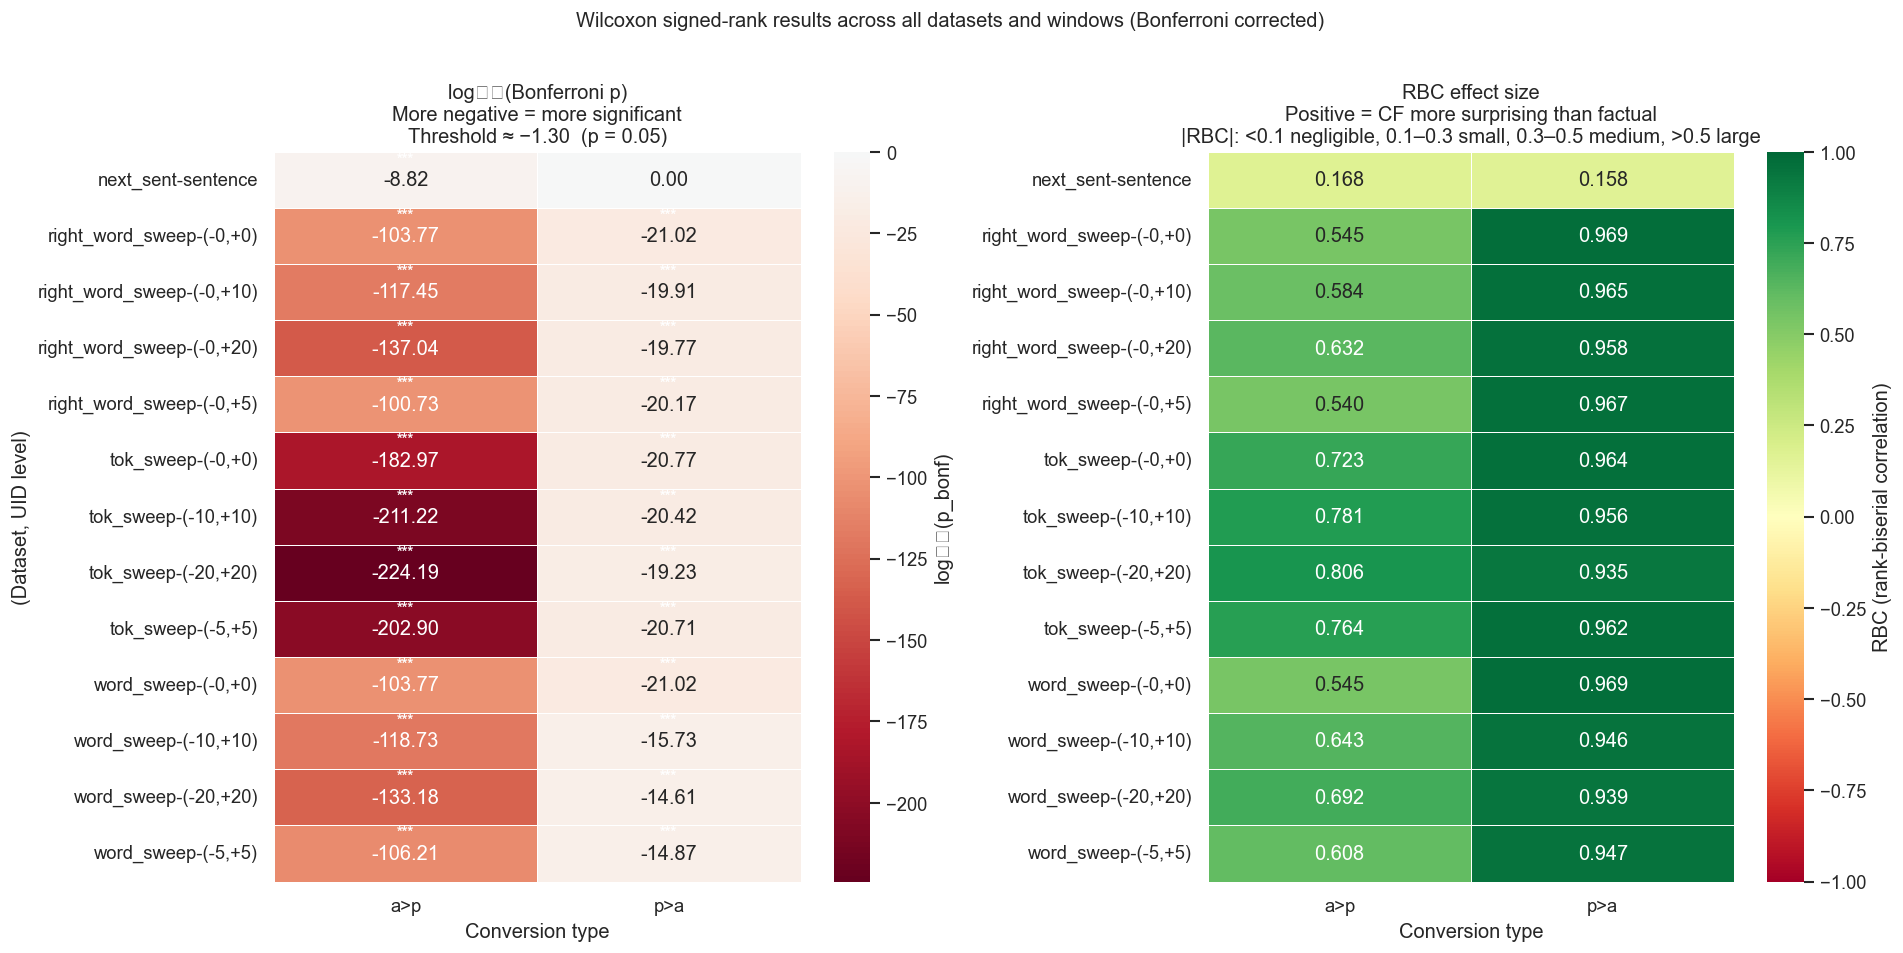

In [11]:
# (Self-contained: _sig_stars also defined in Cell 12a — redefined here for robustness)
def _sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# 3b. p-value and effect-size heatmap across all datasets × windows × conv_types
# Left:  log10(p_bonf) — more negative = more significant; threshold log10(0.05) ≈ -1.30
# Right: RBC effect size (rank-biserial correlation)
# Requires wilcoxon_results (Cell 12).

def _make_pivot(col, fill=np.nan):
    return wilcoxon_results.pivot_table(
        index=["dataset", "uid_level"],
        columns="conv_type",
        values=col,
        aggfunc="first",
    ).fillna(fill)


piv_p_raw = _make_pivot("p_bonf", fill=1.0)
piv_rbc   = _make_pivot("RBC",    fill=0.0)

_log10fn = lambda p: np.log10(max(p, 1e-300)) if not np.isnan(p) else np.nan
piv_log10p = (
    piv_p_raw.applymap(_log10fn)
    if hasattr(pd.DataFrame, "applymap")
    else piv_p_raw.map(_log10fn)
)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(piv_log10p) * 0.45 + 2)))

# ── Left: log10(p_bonf) ──────────────────────────────────────────────────────
_vmin = float(piv_log10p.min().min())
sns.heatmap(
    piv_log10p,
    ax=axes[0],
    cmap="RdBu",
    center=np.log10(0.05),
    annot=True, fmt=".2f",
    linewidths=0.4,
    vmin=_vmin, vmax=0.0,
    cbar_kws={"label": "log\u2081\u2080(p_bonf)"},
)
axes[0].set_title(
    "log\u2081\u2080(Bonferroni p)\n"
    "More negative = more significant\n"
    "Threshold \u2248 \u22121.30  (p = 0.05)"
)
axes[0].set_xlabel("Conversion type")
axes[0].set_ylabel("(Dataset, UID level)")

# Overlay significance stars in white on significant cells
for i, (ridx, row) in enumerate(piv_log10p.iterrows()):
    for j, (cidx, val) in enumerate(row.items()):
        if np.isnan(val):
            continue
        p = 10 ** val
        stars = _sig_stars(p)
        if stars != "ns":
            axes[0].text(j + 0.5, i + 0.25, stars,
                         ha="center", va="bottom", fontsize=9,
                         color="white", fontweight="bold")

# ── Right: RBC ──────────────────────────────────────────────────────────────
sns.heatmap(
    piv_rbc,
    ax=axes[1],
    cmap="RdYlGn",
    center=0,
    annot=True, fmt=".3f",
    linewidths=0.4,
    vmin=-1, vmax=1,
    cbar_kws={"label": "RBC (rank-biserial correlation)"},
)
axes[1].set_title(
    "RBC effect size\n"
    "Positive = CF more surprising than factual\n"
    "|RBC|: <0.1 negligible, 0.1\u20130.3 small, 0.3\u20130.5 medium, >0.5 large"
)
axes[1].set_xlabel("Conversion type")
axes[1].set_ylabel("")

plt.suptitle(
    "Wilcoxon signed-rank results across all datasets and windows (Bonferroni corrected)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_significance_heatmap.png", bbox_inches="tight")
plt.show()


In [12]:
# (Self-contained: MIN_GENRE_N defined in Cell 10; redefined here as fallback)
if "MIN_GENRE_N" not in dir():
    MIN_GENRE_N = 10

# _sig_stars defined in Cell 12a; redefined here as fallback
if "_sig_stars" not in dir():
    def _sig_stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

# 3c. Per-genre Wilcoxon tests (EXPLORATORY — interpret with caution)
# Requires: MIN_GENRE_N and _sig_stars (Cell 10 and 12a),
#           right_paired (Cell 4), pg and multipletests (Cell 2).
#
# WARNING: Correction applied WITHIN this sub-analysis only.
# NOT jointly corrected with the main Wilcoxon table in Cell 12.

sub = right_paired[right_paired["uid_level"] == "(-0,+0)"].copy()
genre_col = "genre_f" if "genre_f" in sub.columns else "genre"

genre_rows = []
for genre, grp in sub.groupby(genre_col):
    for ct in ["a>p", "p>a"]:
        vals = grp[grp["conv_type"] == ct][["surp_mean_cf", "surp_mean_f"]].dropna()
        n = len(vals)
        if n < MIN_GENRE_N:
            continue
        try:
            res = pg.wilcoxon(vals["surp_mean_cf"], vals["surp_mean_f"])
            genre_rows.append({
                "genre":        genre,
                "conv_type":    ct,
                "n":            n,
                "median_delta": (vals["surp_mean_cf"] - vals["surp_mean_f"]).median(),
                "W":            res["W_val"].iloc[0],
                "p_raw":        res["p_val"].iloc[0],
                "RBC":          res["RBC"].iloc[0],
            })
        except Exception as e:
            print(f"  Skipped {genre} {ct}: {e}")

genre_wilcoxon = pd.DataFrame(genre_rows)

if genre_wilcoxon.empty:
    print(f"No genre has n >= {MIN_GENRE_N} for any conversion type.")
else:
    _, genre_wilcoxon["p_bonf"], _, _ = multipletests(
        genre_wilcoxon["p_raw"], method="bonferroni"
    )
    genre_wilcoxon["sig_bonf"] = genre_wilcoxon["p_bonf"] < 0.05
    genre_wilcoxon["stars"]    = genre_wilcoxon["p_bonf"].apply(_sig_stars)

    print("=" * 65)
    print("Per-genre Wilcoxon results (EXPLORATORY)")
    print("Bonferroni corrected WITHIN this sub-analysis only.")
    print("NOT jointly corrected with the main Wilcoxon table.")
    print("=" * 65)
    print(genre_wilcoxon.sort_values(["conv_type", "p_bonf"]).to_string(index=False))
    print()
    print("NOTE: p>a genre results should be treated with extreme caution (low n).")
    sig = genre_wilcoxon[genre_wilcoxon["sig_bonf"]]
    if len(sig):
        print(f"\nSignificant genres after genre-level Bonferroni correction (n={len(sig)}):")
        print(sig[["genre", "conv_type", "n", "median_delta", "p_bonf", "RBC", "stars"]]
              .to_string(index=False))
    else:
        print("\nNo genre survives genre-level Bonferroni correction.")


Per-genre Wilcoxon results (EXPLORATORY)
Bonferroni corrected WITHIN this sub-analysis only.
NOT jointly corrected with the main Wilcoxon table.
       genre conv_type   n  median_delta         W  p_raw    RBC  p_bonf  sig_bonf stars
        vlog       a>p 205        0.2571 3761.0000 0.0000 0.6331  0.0000      True   ***
      speech       a>p 186        0.3372 2952.0000 0.0000 0.6531  0.0000      True   ***
         bio       a>p 176        0.3202 2068.0000 0.0000 0.6789  0.0000      True   ***
conversation       a>p 240        0.2986 5908.0000 0.0000 0.5590  0.0000      True   ***
        whow       a>p 143        0.3310 1354.0000 0.0000 0.6961  0.0000      True   ***
     fiction       a>p 202        0.2648 4777.0000 0.0000 0.5051  0.0000      True   ***
   interview       a>p 243        0.1221 6734.0000 0.0000 0.4510  0.0000      True   ***
    textbook       a>p 172        0.1504 2672.0000 0.0000 0.5404  0.0000      True   ***
        news       a>p 161        0.1452 3276.0000 0.0

In [13]:
# Effect size summary
print("=== Significant results (Bonferroni p < 0.05) ===")
sig = wilcoxon_results[wilcoxon_results["sig_bonf"]]
if len(sig) == 0:
    print("None after Bonferroni correction.")
    print("\nSignificant after FDR correction:")
    print(wilcoxon_results[wilcoxon_results["sig_fdr"]][["dataset", "uid_level", "conv_type", "n", "median_delta", "p_fdr", "RBC"]].to_string(index=False))
else:
    print(sig[["dataset", "uid_level", "conv_type", "n", "median_delta", "p_bonf", "RBC"]].to_string(index=False))

print("\nRBC interpretation: |r| < 0.1 = negligible, 0.1–0.3 = small, 0.3–0.5 = medium, >0.5 = large")

=== Significant results (Bonferroni p < 0.05) ===
         dataset uid_level conv_type    n  median_delta  p_bonf    RBC
       tok_sweep   (-0,+0)       a>p 2304        0.2651  0.0000 0.7228
       tok_sweep   (-0,+0)       p>a  139        0.6197  0.0000 0.9636
       tok_sweep   (-5,+5)       a>p 2281        0.2117  0.0000 0.7642
       tok_sweep   (-5,+5)       p>a  139        0.4216  0.0000 0.9622
       tok_sweep (-10,+10)       a>p 2274        0.1806  0.0000 0.7806
       tok_sweep (-10,+10)       p>a  139        0.3453  0.0000 0.9556
       tok_sweep (-20,+20)       a>p 2259        0.1362  0.0000 0.8063
       tok_sweep (-20,+20)       p>a  137        0.2385  0.0000 0.9348
      word_sweep   (-0,+0)       a>p 2300        0.2043  0.0000 0.5449
      word_sweep   (-0,+0)       p>a  139        0.9301  0.0000 0.9692
      word_sweep   (-5,+5)       a>p 1888        0.1684  0.0000 0.6082
      word_sweep   (-5,+5)       p>a  104        0.5971  0.0000 0.9469
      word_sweep (-10,+10) 

## 4 — Linear Mixed-Effects Models

Controls for by-document variability via random intercepts. Gold standard for psycholinguistic data.

In [14]:
def lme_condition_effect(df, metric="surp_mean", label=""):
    """Model: metric ~ condition + conv_type, random intercept by doc_name."""
    # Build long-format dataframe: one row per sentence (factual or CF)
    f_cols = [c for c in df.columns if c.endswith("_f") and not c.startswith("delta")]
    cf_cols = [c for c in df.columns if c.endswith("_cf") and not c.startswith("delta")]
    base_cols = ["doc_name", "conv_type", "sent_idx"]
    if "uid_level" in df.columns:
        base_cols.append("uid_level")

    factual_long = df[base_cols + f_cols].copy()
    factual_long.columns = base_cols + [c[:-2] for c in f_cols]
    factual_long["condition"] = 0

    cf_long = df[base_cols + cf_cols].copy()
    cf_long.columns = base_cols + [c[:-3] for c in cf_cols]
    cf_long["condition"] = 1

    long = pd.concat([factual_long, cf_long], ignore_index=True)
    long = long.dropna(subset=[metric, "doc_name"])

    # Encode conv_type as dummy (a>p = 0 reference)
    long["conv_p2a"] = (long["conv_type"] == "p>a").astype(int)

    try:
        model = smf.mixedlm(
            f"{metric} ~ condition + conv_p2a",
            data=long,
            groups=long["doc_name"],
        ).fit(reml=True)
        print(f"\n{'='*60}")
        print(f"LME: {label}  |  outcome: {metric}")
        print(f"{'='*60}")
        print(model.summary().tables[1])
        return model
    except Exception as e:
        print(f"Model failed for {label}: {e}")
        return None


# Model 1: Basic condition effect — word sweep, (-0,+0) window
sub_word_0 = word_paired[word_paired["uid_level"] == "(-0,+0)"]
m1 = lme_condition_effect(sub_word_0, metric="surp_mean", label="word sweep (-0,+0)")


LME: word sweep (-0,+0)  |  outcome: surp_mean
            Coef. Std.Err.        z  P>|z|  [0.025 0.975]
Intercept   6.854    0.067  102.545  0.000   6.723  6.985
condition   0.403    0.049    8.306  0.000   0.308  0.499
conv_p2a   -0.149    0.110   -1.354  0.176  -0.365  0.067
Group Var   0.546    0.043                               


In [15]:
# Model 2: Next-sentence effect
m2 = lme_condition_effect(nxt_paired, metric="surp_mean", label="next-sentence UID")


LME: next-sentence UID  |  outcome: surp_mean
           Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept  7.130    0.096  74.571  0.000   6.942  7.317
condition  0.061    0.071   0.869  0.385  -0.077  0.200
conv_p2a   0.219    0.159   1.377  0.168  -0.093  0.531
Group Var  1.099    0.061                              


In [16]:
# Model 3: surp_slor as secondary outcome (controls for word frequency)
# If significant here, the effect isn't just due to frequency differences between active/passive words
m3 = lme_condition_effect(sub_word_0, metric="surp_slor", label="word sweep (-0,+0) — SLOR")


LME: word sweep (-0,+0) — SLOR  |  outcome: surp_slor
            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept   3.421    0.083   41.177  0.000   3.258   3.584
condition  -0.521    0.047  -11.155  0.000  -0.612  -0.429
conv_p2a    0.348    0.107    3.266  0.001   0.139   0.557
Group Var   0.990    0.074                                


In [17]:
# Model 4 — Right-only window modulation
# Does the condition effect change as we include more right-context tokens?
# condition:right_window < 0 → right-context tokens show smaller delta than s_t tokens
# condition:right_window > 0 → right-context amplifies the effect

RIGHT_ONLY_SIZE = {"(-0,+0)": 0, "(-0,+5)": 5, "(-0,+10)": 10, "(-0,+20)": 20}

right_with_size = right_paired.copy()
right_with_size["right_window"] = right_with_size["uid_level"].map(RIGHT_ONLY_SIZE)
right_with_size = right_with_size.dropna(subset=["right_window"])

rows_f  = right_with_size[["doc_name", "conv_type", "sent_idx", "uid_level", "right_window", "surp_mean_f"]].copy()
rows_cf = right_with_size[["doc_name", "conv_type", "sent_idx", "uid_level", "right_window", "surp_mean_cf"]].copy()
rows_f.rename( columns={"surp_mean_f":  "surp_mean"}, inplace=True); rows_f["condition"]  = 0
rows_cf.rename(columns={"surp_mean_cf": "surp_mean"}, inplace=True); rows_cf["condition"] = 1

long_right = pd.concat([rows_f, rows_cf], ignore_index=True).dropna(subset=["surp_mean", "doc_name"])
long_right["conv_p2a"] = (long_right["conv_type"] == "p>a").astype(int)

try:
    m4 = smf.mixedlm(
        "surp_mean ~ condition * right_window + conv_p2a",
        data=long_right,
        groups=long_right["doc_name"],
    ).fit(reml=True)
    print("LME Model 4 — right-only window modulation (surp_mean):")
    print(m4.summary().tables[1])
    print()
    print("Key coefficients:")
    print("  condition        = effect at right_window=0 (s_t tokens only)")
    print("  condition:right_window = change in effect per additional right-context token")
    print("  Negative interaction → right-context tokens have smaller delta than s_t tokens")
    print("  This directly tests whether the conversion effect decays into right context")
except Exception as e:
    print(f"Model 4 failed: {e}")

LME Model 4 — right-only window modulation (surp_mean):
                         Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                6.951    0.064  109.425  0.000   6.827   7.076
condition                0.379    0.032   11.830  0.000   0.316   0.442
right_window            -0.010    0.002   -5.214  0.000  -0.014  -0.006
condition:right_window  -0.007    0.003   -2.451  0.014  -0.012  -0.001
conv_p2a                -0.117    0.048   -2.432  0.015  -0.211  -0.023
Group Var                0.615    0.048                                

Key coefficients:
  condition        = effect at right_window=0 (s_t tokens only)
  condition:right_window = change in effect per additional right-context token
  Negative interaction → right-context tokens have smaller delta than s_t tokens
  This directly tests whether the conversion effect decays into right context


## 5 — Right-only Window Sweep

The right-only sweep `(-0,+k)` is the clean version of the window analysis. Left-side window tokens are **identical between factual and CF conditions** (causal LM: same preceding context, same preceding words), so they contribute exactly 0 to the factual–CF delta. Adding them to a symmetric window only dilutes the measured effect.

By sweeping the right window from 0 → 5 → 10 → 20 tokens, we can estimate how surprising the right-context tokens (from s_{t+1}) are in the CF vs factual condition. This is a direct, continuous measurement of how far the conversion effect propagates to the right.

**Interpretation of the incremental delta:**
If the right-context tokens have a smaller delta than s_t tokens, the conversion effect is decaying as we move into s_{t+1}. If they have a larger delta, the effect is amplified. The incremental calculation isolates the right-context contribution per token.

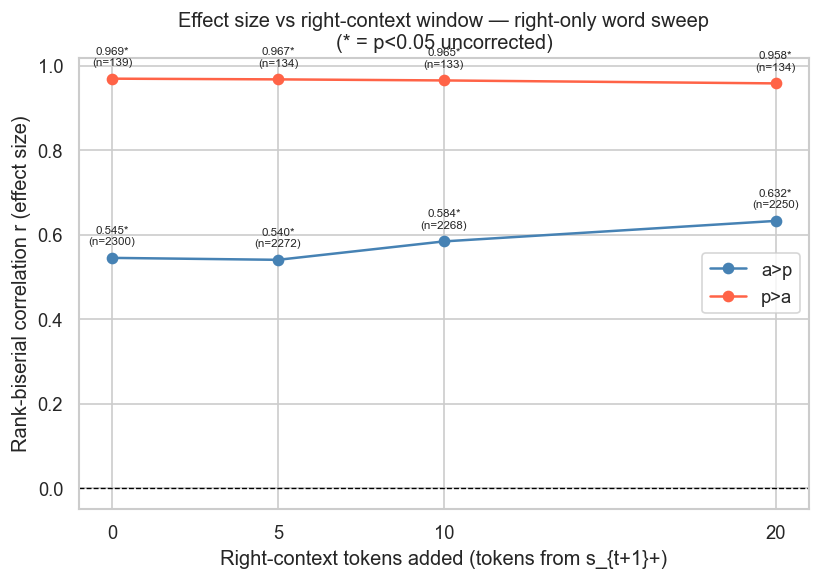

uid_level  right_tokens conv_type    n    RBC      p  median_delta
  (-0,+0)             0       a>p 2300 0.5449 0.0000        0.2043
  (-0,+0)             0       p>a  139 0.9692 0.0000        0.9301
  (-0,+5)             5       a>p 2272 0.5403 0.0000        0.1639
  (-0,+5)             5       p>a  134 0.9675 0.0000        0.7350
 (-0,+10)            10       a>p 2268 0.5839 0.0000        0.1554
 (-0,+10)            10       p>a  133 0.9650 0.0000        0.6456
 (-0,+20)            20       a>p 2250 0.6324 0.0000        0.1385
 (-0,+20)            20       p>a  134 0.9580 0.0000        0.4980

── Incremental right-context delta per token (a>p only) ──
Mean s_t length: 18.1 words
Mean Δ at (-0,+0)  [s_t only]:    0.3616 bits/word
Window          Mean Δ    δ_r (avg per tok)  Interpretation
(-0,+5)         0.2875               0.0199  (+6% of s_t effect)
(-0,+10)        0.2733               0.1139  (+32% of s_t effect)
(-0,+20)        0.2364               0.1233  (+34% of s_t effect)



In [18]:
# 5a. Effect size (RBC) vs right-context window size
RIGHT_ONLY_SIZE = {"(-0,+0)": 0, "(-0,+5)": 5, "(-0,+10)": 10, "(-0,+20)": 20}

def effect_size_by_right_window(paired_df, window_map, metric="surp_mean"):
    rows = []
    for uid_level, x in window_map.items():
        for ct in ["a>p", "p>a"]:
            sub = paired_df[
                (paired_df["uid_level"] == uid_level) & (paired_df["conv_type"] == ct)
            ][[f"{metric}_cf", f"{metric}_f"]].dropna()
            if len(sub) < 10:
                continue
            res = pg.wilcoxon(sub[f"{metric}_cf"], sub[f"{metric}_f"])
            rows.append({
                "uid_level": uid_level,
                "right_tokens": x,
                "conv_type": ct,
                "n": len(sub),
                "RBC": res["RBC"].iloc[0],
                "p": res["p_val"].iloc[0],
                "median_delta": (sub[f"{metric}_cf"] - sub[f"{metric}_f"]).median(),
            })
    return pd.DataFrame(rows)

es_right = effect_size_by_right_window(right_paired, RIGHT_ONLY_SIZE)

fig, ax = plt.subplots(figsize=(7, 5))
for ct, color in [("a>p", "steelblue"), ("p>a", "tomato")]:
    sub = es_right[es_right["conv_type"] == ct].sort_values("right_tokens")
    ax.plot(sub["right_tokens"], sub["RBC"], marker="o", label=ct, color=color)
    for _, row in sub.iterrows():
        marker = "*" if row["p"] < 0.05 else ""
        ax.annotate(f"{row['RBC']:.3f}{marker}\n(n={row['n']})",
                    (row["right_tokens"], row["RBC"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Right-context tokens added (tokens from s_{t+1}+)")
ax.set_ylabel("Rank-biserial correlation r (effect size)")
ax.set_title("Effect size vs right-context window — right-only word sweep\n(* = p<0.05 uncorrected)")
ax.legend()
ax.set_xticks([0, 5, 10, 20])
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_rbc_right_sweep.png", bbox_inches="tight")
plt.show()

print(es_right.to_string(index=False))

# ── 5b. Incremental delta: right-context contribution per token ───────────────
# delta_k = (n_st * delta_0 + k * delta_r_k) / (n_st + k)
# => delta_r(0→k) = (delta_k * (n_st + k) - delta_0 * n_st) / k
# This estimates the average per-token delta for the first k right-context tokens.

print("\n── Incremental right-context delta per token (a>p only) ──")
base_0 = right_paired[(right_paired["uid_level"] == "(-0,+0)") & (right_paired["conv_type"] == "a>p")]
n_st = base_0["uid_len_f"].mean()
delta_0 = (base_0["surp_mean_cf"] - base_0["surp_mean_f"]).mean()
print(f"Mean s_t length: {n_st:.1f} words")
print(f"Mean Δ at (-0,+0)  [s_t only]:    {delta_0:.4f} bits/word")
print(f"{'Window':<12} {'Mean Δ':>9} {'δ_r (avg per tok)':>20}  Interpretation")

for win_label, k in [("(-0,+5)", 5), ("(-0,+10)", 10), ("(-0,+20)", 20)]:
    sub_k = right_paired[(right_paired["uid_level"] == win_label) & (right_paired["conv_type"] == "a>p")]
    delta_k = (sub_k["surp_mean_cf"] - sub_k["surp_mean_f"]).mean()
    delta_r = (delta_k * (n_st + k) - delta_0 * n_st) / k
    pct = delta_r / delta_0 * 100
    print(f"{win_label:<12} {delta_k:>9.4f} {delta_r:>20.4f}  ({pct:+.0f}% of s_t effect)")

print(f"\nRight-context δ_r is much smaller than the s_t delta ({delta_0:.3f}) → conversion effect decays rapidly.")
print("This is corroborated by next_sent_uid (Section 6): median Δ s_{t+1} ≈ +0.007 bits/word.")

## 6 — Next-Sentence Analysis

Two complementary measurements of whether the s_t conversion ripples forward into s_{t+1}:

1. **Right sweep decomposition** (Section 5): the incremental delta per right-context token estimates how surprising s_{t+1} tokens become after conversion. The per-token delta is ~15–34% of the s_t effect.

2. **Direct s_{t+1} scoring** (`next_sent_uid.csv`): the full s_{t+1} sentence is scored given the modified context (factual: after s_t; CF: after cf(s_t)). This gives a direct sentence-level Δ for s_{t+1}.

Both methods agree on the core finding: **the conversion effect is primarily local to s_t**. There is a detectable but substantively small ripple into s_{t+1}.

> Note: `next_sent_uid` uses `uid_level=sentence` — it scores only s_{t+1} tokens, so it is measuring purely the discourse context effect (how the model predicts s_{t+1} differently given a different s_t). The right sweep captures the same tokens via a different extraction path.

In [19]:
# 6a. Direct s_{t+1} scoring — Wilcoxon + summary statistics
print("=== Direct s_{t+1} scoring (next_sent_uid) ===\n")
for ct in ["a>p", "p>a"]:
    sub = nxt_paired[nxt_paired["conv_type"] == ct]
    delta = sub["delta_surp_mean"].dropna()
    if len(delta) < 5:
        print(f"  {ct}: n={len(delta)} (too few)")
        continue
    common = sub["surp_mean_cf"].dropna().index.intersection(sub["surp_mean_f"].dropna().index)
    res = pg.wilcoxon(sub.loc[common, "surp_mean_cf"], sub.loc[common, "surp_mean_f"])
    print(f"  {ct}: n={len(common)}")
    print(f"    median Δ = {delta.median():+.4f} bits/word")
    print(f"    mean   Δ = {delta.mean():+.4f} bits/word")
    print(f"    W={res['W_val'].iloc[0]:.0f}, p={res['p_val'].iloc[0]:.4f}, RBC={res['RBC'].iloc[0]:.4f}")

print()

# 6b. Side-by-side: s_t effect vs s_{t+1} effect (a>p only, mean Δ)
base_0 = right_paired[(right_paired["uid_level"]=="(-0,+0)") & (right_paired["conv_type"]=="a>p")]
n_st   = base_0["uid_len_f"].mean()
delta_st_mean = (base_0["surp_mean_cf"] - base_0["surp_mean_f"]).mean()

nxt_a2p = nxt_paired[nxt_paired["conv_type"] == "a>p"]["delta_surp_mean"].dropna()
delta_st1_mean = nxt_a2p.mean()

# Incremental per-token right-context deltas
incremental = {}
for win_label, k in [("(-0,+5)", 5), ("(-0,+10)", 10), ("(-0,+20)", 20)]:
    sub_k = right_paired[(right_paired["uid_level"]==win_label) & (right_paired["conv_type"]=="a>p")]
    delta_k = (sub_k["surp_mean_cf"] - sub_k["surp_mean_f"]).mean()
    incremental[k] = (delta_k * (n_st + k) - delta_st_mean * n_st) / k

print("── Comparing s_t effect vs right-context/s_{t+1} effect (a>p, mean Δ bits/word) ──")
print(f"  s_t only (-0,+0):           {delta_st_mean:+.4f}  (reference)")
print(f"  First  5 right-ctx tokens:  {incremental[5]:+.4f}  ({incremental[5]/delta_st_mean*100:+.0f}% of s_t)")
print(f"  First 10 right-ctx tokens:  {incremental[10]:+.4f}  ({incremental[10]/delta_st_mean*100:+.0f}% of s_t)")
print(f"  First 20 right-ctx tokens:  {incremental[20]:+.4f}  ({incremental[20]/delta_st_mean*100:+.0f}% of s_t)")
print(f"  Full s_{{t+1}} (next_sent):   {delta_st1_mean:+.4f}  ({delta_st1_mean/delta_st_mean*100:+.0f}% of s_t)")
print()
print("Conclusion: the conversion primarily affects s_t. The right-context / s_{t+1} effect")
print("is positive (same direction) but roughly 15–35% the size per token, or ~2% at the")
print("sentence level. Both measurements confirm the same story.")

=== Direct s_{t+1} scoring (next_sent_uid) ===

  a>p: n=2164
    median Δ = +0.0066 bits/word
    mean   Δ = +0.0625 bits/word
    W=850653, p=0.0000, RBC=0.1682
  p>a: n=133
    median Δ = +0.0073 bits/word
    mean   Δ = +0.0429 bits/word
    W=3751, p=0.1139, RBC=0.1581

── Comparing s_t effect vs right-context/s_{t+1} effect (a>p, mean Δ bits/word) ──
  s_t only (-0,+0):           +0.3616  (reference)
  First  5 right-ctx tokens:  +0.0199  (+6% of s_t)
  First 10 right-ctx tokens:  +0.1139  (+32% of s_t)
  First 20 right-ctx tokens:  +0.1233  (+34% of s_t)
  Full s_{t+1} (next_sent):   +0.0625  (+17% of s_t)

Conclusion: the conversion primarily affects s_t. The right-context / s_{t+1} effect
is positive (same direction) but roughly 15–35% the size per token, or ~2% at the
sentence level. Both measurements confirm the same story.


Cross-referenced pairs (a>p): 2160
Spearman r(Δs_t, Δs_{t+1}) = 0.049,  p = 0.0228
r ≈ 0 → knowing how much s_t was affected doesn't predict how much s_{t+1} is affected


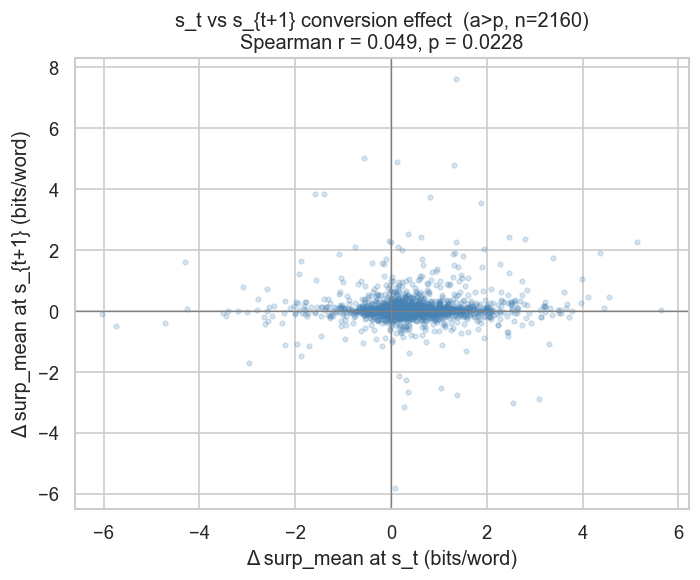

In [20]:
# 6c. Cross-reference scatter: Δ s_t vs Δ s_{t+1}
# Does converting sentences that became MORE surprising also make their next sentences more surprising?

st_delta = right_paired[
    (right_paired["uid_level"] == "(-0,+0)") & (right_paired["conv_type"] == "a>p")
][["doc_name", "sent_idx", "conv_type", "delta_surp_mean"]].copy()
st_delta.rename(columns={"delta_surp_mean": "delta_st", "sent_idx": "source_sent_idx"}, inplace=True)

nxt_delta = nxt_paired[nxt_paired["conv_type"] == "a>p"][
    ["doc_name", "sent_idx", "conv_type", "delta_surp_mean"]
].copy()
nxt_delta["source_sent_idx"] = nxt_delta["sent_idx"] - 1
nxt_delta.rename(columns={"delta_surp_mean": "delta_st1"}, inplace=True)

cross = st_delta.merge(nxt_delta, on=["doc_name", "source_sent_idx", "conv_type"])
print(f"Cross-referenced pairs (a>p): {len(cross)}")

if len(cross) > 10:
    r, p = stats.spearmanr(cross["delta_st"].dropna(), cross["delta_st1"].dropna())
    print(f"Spearman r(Δs_t, Δs_{{t+1}}) = {r:.3f},  p = {p:.4f}")
    print("r ≈ 0 → knowing how much s_t was affected doesn't predict how much s_{t+1} is affected")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(cross["delta_st"], cross["delta_st1"], alpha=0.2, s=8, color="steelblue")
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_xlabel("Δ surp_mean at s_t (bits/word)")
    ax.set_ylabel("Δ surp_mean at s_{t+1} (bits/word)")
    ax.set_title(f"s_t vs s_{{t+1}} conversion effect  (a>p, n={len(cross)})\nSpearman r = {r:.3f}, p = {p:.4f}")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "fig_st_vs_st1.png", bbox_inches="tight")
    plt.show()

## 7 — Multi-Sentence & Document-Level Trajectory

Does the conversion effect at s_t ripple forward through the document?

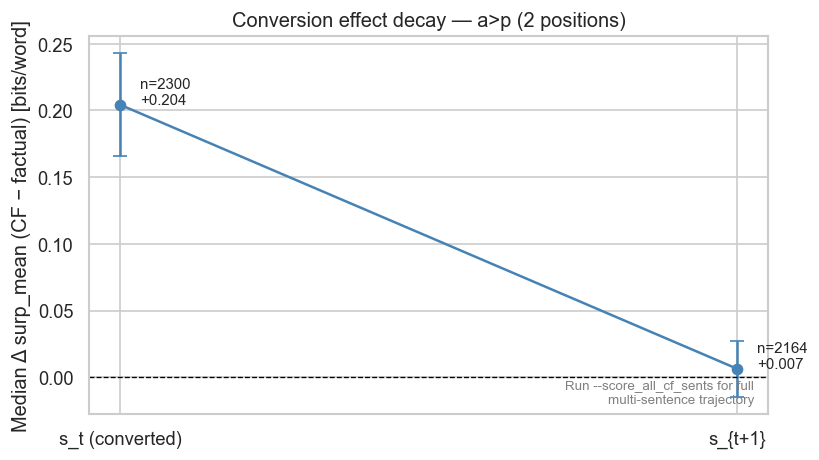

In [21]:
# 7a. Decay curve: conversion effect at s_t and s_{t+1} (approximation with existing data)
# Δ at s_t   : from right_paired (-0,+0), a>p
# Δ at s_{t+1}: from nxt_paired, a>p

delta_t  = right_paired[
    (right_paired["uid_level"] == "(-0,+0)") & (right_paired["conv_type"] == "a>p")
]["delta_surp_mean"].dropna()

delta_t1 = nxt_paired[nxt_paired["conv_type"] == "a>p"]["delta_surp_mean"].dropna()

positions = [0, 1]
medians = [delta_t.median(), delta_t1.median()]
cis = [
    stats.sem(delta_t)  * stats.t.ppf(0.975, len(delta_t)  - 1),
    stats.sem(delta_t1) * stats.t.ppf(0.975, len(delta_t1) - 1),
]
ns = [len(delta_t), len(delta_t1)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(positions, medians, yerr=cis, marker="o", color="steelblue", capsize=4)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(positions)
ax.set_xticklabels(["s_t (converted)", "s_{t+1}"])
ax.set_ylabel("Median Δ surp_mean (CF − factual) [bits/word]")
ax.set_title("Conversion effect decay — a>p (2 positions)")
for x, m, n in zip(positions, medians, ns):
    ax.annotate(f"n={n}\n{m:+.3f}", (x, m), textcoords="offset points", xytext=(12, 0), fontsize=9)
ax.text(0.98, 0.02,
        "Run --score_all_cf_sents for full\nmulti-sentence trajectory",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_decay_curve_partial.png", bbox_inches="tight")
plt.show()

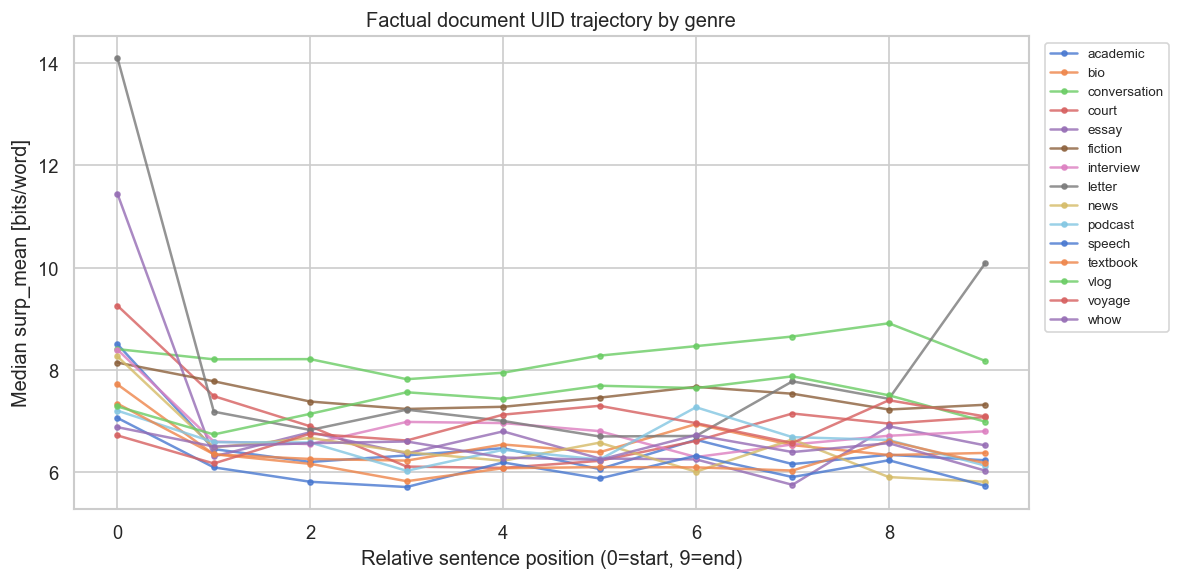

In [22]:
# 7b. Factual document UID trajectories by genre
# Use all factual sentences from word sweep (-0,+0) to visualise within-document UID profiles

factual_word = word[word["fact"] == "f"].copy()
factual_word = factual_word[factual_word["uid_level"] == "(-0,+0)"]

# Compute relative sentence position (0 = first, normalised to [0,1])
doc_len = factual_word.groupby("doc_name")["sent_idx"].transform("max").clip(lower=1)
factual_word["rel_pos"] = factual_word["sent_idx"] / doc_len
factual_word["pos_bin"] = pd.cut(factual_word["rel_pos"], bins=10, labels=False)

fig, ax = plt.subplots(figsize=(10, 5))
traj_by_genre = factual_word.groupby(["genre", "pos_bin"])["surp_mean"].median().reset_index()
for genre, g in traj_by_genre.groupby("genre"):
    ax.plot(g["pos_bin"], g["surp_mean"], marker=".", label=genre, alpha=0.8)

ax.set_xlabel("Relative sentence position (0=start, 9=end)")
ax.set_ylabel("Median surp_mean [bits/word]")
ax.set_title("Factual document UID trajectory by genre")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_factual_trajectories.png", bbox_inches="tight")
plt.show()

In [23]:
# 7c. Full trajectory analysis — only runs if full_cf_traj.csv exists
if traj_paired is not None:
    # Compute relative position of each sentence to the conversion point
    # source_sent_idx_cf = the converted sentence position
    if "source_sent_idx" in traj_paired.columns:
        traj_paired["rel_pos"] = traj_paired["sent_idx"] - traj_paired["source_sent_idx"]
    else:
        traj_paired["rel_pos"] = traj_paired["sent_idx"] - traj_paired["conv_id"].astype(int)

    # Restrict to window [-3, +3] around conversion
    near = traj_paired[traj_paired["rel_pos"].between(-3, 3)]
    curve = near.groupby(["rel_pos", "conv_type"])["delta_surp_mean"].agg(["median", "sem", "count"]).reset_index()

    fig, ax = plt.subplots(figsize=(9, 5))
    for ct, color in [("a>p", "steelblue"), ("p>a", "tomato")]:
        sub = curve[curve["conv_type"] == ct].sort_values("rel_pos")
        ci = sub["sem"] * 1.96
        ax.plot(sub["rel_pos"], sub["median"], marker="o", label=ct, color=color)
        ax.fill_between(sub["rel_pos"], sub["median"] - ci, sub["median"] + ci, alpha=0.2, color=color)

    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.axvline(0, color="grey", lw=0.8, ls=":", label="conversion point")
    ax.set_xlabel("Sentence position relative to conversion (0 = s_t)")
    ax.set_ylabel("Median Δ surp_mean (CF − factual)")
    ax.set_title("Full conversion effect trajectory")
    ax.legend()
    ax.set_xticks(range(-3, 4))
    plt.tight_layout()
    plt.savefig(DATA_DIR / "fig_full_trajectory.png", bbox_inches="tight")
    plt.show()

    # Document-level UID variance
    doc_uid_f = traj_paired.groupby("doc_name")["surp_mean_f"].std().rename("doc_uid_std_f")
    doc_uid_cf = traj_paired.groupby("doc_name")["surp_mean_cf"].std().rename("doc_uid_std_cf")
    doc_uid = pd.concat([doc_uid_f, doc_uid_cf], axis=1).dropna()
    doc_uid["delta_doc_std"] = doc_uid["doc_uid_std_cf"] - doc_uid["doc_uid_std_f"]
    r, p = stats.wilcoxon(doc_uid["doc_uid_std_cf"], doc_uid["doc_uid_std_f"])
    print(f"Document-level UID variance: median Δ={doc_uid['delta_doc_std'].median():.4f}")
    print(f"Wilcoxon: W={r:.0f}, p={p:.4f}")
    print("Positive Δ = conversion increases document-level UID variability")
else:
    print("full_cf_traj.csv not found.")
    print("Generate it with:")
    print("  uv run python scripts/run_windowed_uid.py data/ gpt2-xl \\")
    print("      --context document --uid_unit word --uid_level '(-0,+0)' \\")
    print("      --generate_counterfactual --score_all_cf_sents \\")
    print("      --fast --batch_size 128 --output_dir outputs --output_name full_cf_traj.csv")

full_cf_traj.csv not found.
Generate it with:
  uv run python scripts/run_windowed_uid.py data/ gpt2-xl \
      --context document --uid_unit word --uid_level '(-0,+0)' \
      --generate_counterfactual --score_all_cf_sents \
      --fast --batch_size 128 --output_dir outputs --output_name full_cf_traj.csv


## 8 — Context vs Calculation Window (Disentangling Effects)

This section separates two effects:
1. **Evaluation-window dilution**: changing `uid_level` changes which tokens are averaged, so CF−F differences usually shrink as more unchanged tokens are included.
2. **Context conditioning**: changing `context` while keeping target evaluation fixed (`uid_level = (-0,+0)`) tests discourse-conditioning directly.


In [24]:
# 8a. Quantify dilution in current sweep (context fixed = document)
dil = word_paired.groupby(['uid_level','conv_type'])['delta_surp_mean'].agg(['count','mean','median','std']).reset_index()
print('Current files have fixed context=\'document\'; this table isolates evaluation-window effects:')
print(dil.sort_values(['conv_type','uid_level']).to_string(index=False))


Current files have fixed context='document'; this table isolates evaluation-window effects:
uid_level conv_type  count   mean  median    std
  (-0,+0)       a>p   2300 0.3616  0.2043 0.9404
(-10,+10)       a>p   1883 0.2375  0.1559 0.4190
(-20,+20)       a>p   1825 0.1914  0.1285 0.3078
  (-5,+5)       a>p   1888 0.2784  0.1684 0.5461
  (-0,+0)       p>a    139 1.0948  0.9301 0.9192
(-10,+10)       p>a    110 0.5039  0.4729 0.3724
(-20,+20)       p>a    104 0.3607  0.3421 0.2934
  (-5,+5)       p>a    104 0.6530  0.5971 0.5092


In [25]:
# 8b. Optional context-only test (requires a CSV with multiple context levels)
ctx_path = DATA_DIR / 'context_word_sentence.csv'
if ctx_path.exists():
    ctx = add_metrics_from_raw(load_and_parse(ctx_path))
    ctx_paired = make_pairs(ctx, merge_cols=('doc_name','sent_idx','uid_level','context'))
    ctx_sub = ctx_paired[ctx_paired['uid_level']=='(-0,+0)'].copy()
    table = ctx_sub.groupby(['context','conv_type'])['delta_surp_mean'].agg(['count','mean','median','std']).reset_index()
    print('Context-only effect (target evaluation fixed at (-0,+0))')
    print(table.sort_values(['conv_type','context']).to_string(index=False))
else:
    print('context_word_sentence.csv not found in DATA_DIR; context-only test skipped.')
    print('To run this test, generate a file with multiple context values while keeping uid_level=(-0,+0).')


context_word_sentence.csv not found in DATA_DIR; context-only test skipped.
To run this test, generate a file with multiple context values while keeping uid_level=(-0,+0).


## Summary Table

In [26]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print("Wilcoxon results (Bonferroni corrected):")
print(wilcoxon_results[[
    "dataset", "uid_level", "conv_type", "n", "median_delta", "p_bonf", "RBC", "sig_bonf"
]].to_string(index=False))
print()
print("Key caveats:")
print("  1. p>a n is small (~130 in next_sent, ~500 in sweep) — interpret with caution")
print("  2. Symmetric windows: left-side tokens are identical between conditions")
print("     → apparent growth with window size reflects right-context dilution only")
print("  3. Run --score_all_cf_sents for full document trajectory analysis (Section 7c)")

SUMMARY

Wilcoxon results (Bonferroni corrected):
         dataset uid_level conv_type    n  median_delta  p_bonf    RBC  sig_bonf
       tok_sweep   (-0,+0)       a>p 2304        0.2651  0.0000 0.7228      True
       tok_sweep   (-0,+0)       p>a  139        0.6197  0.0000 0.9636      True
       tok_sweep   (-5,+5)       a>p 2281        0.2117  0.0000 0.7642      True
       tok_sweep   (-5,+5)       p>a  139        0.4216  0.0000 0.9622      True
       tok_sweep (-10,+10)       a>p 2274        0.1806  0.0000 0.7806      True
       tok_sweep (-10,+10)       p>a  139        0.3453  0.0000 0.9556      True
       tok_sweep (-20,+20)       a>p 2259        0.1362  0.0000 0.8063      True
       tok_sweep (-20,+20)       p>a  137        0.2385  0.0000 0.9348      True
      word_sweep   (-0,+0)       a>p 2300        0.2043  0.0000 0.5449      True
      word_sweep   (-0,+0)       p>a  139        0.9301  0.0000 0.9692      True
      word_sweep   (-5,+5)       a>p 1888        0.1684  0.